In [1]:
# Importando todas as bibliotecas necessárias
import torch
import matplotlib.pyplot as plt
import networkx as nx

# Imports do PyTorch Geometric
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
# IMPORTAÇÃO CORRIGIDA E ADICIONAL:
from torch_geometric.explain import Explainer, GNNExplainer

# IMPORTANTE: Importando NOSSAS classes dos arquivos .py
import sys
sys.path.append('..')
from src.models import GCN

/home/paulo/UFOP/ic/IC-Explainability_of_GNNs/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- PASSO 1: CARREGAR DADOS E MODELO TREINADO ---

# Carregar o dataset Cora
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# Instanciar a arquitetura do nosso modelo
model = GCN(num_features=dataset.num_features, 
            hidden_channels=16, 
            num_classes=dataset.num_classes)

# Carregar os pesos do modelo
model.load_state_dict(torch.load('../gcn_cora.pth'))
model.eval()
print("Modelo e dados carregados com sucesso!")

Processing...
Done!


Modelo e dados carregados com sucesso!


In [3]:
# --- PASSO 2: CONFIGURAR E EXECUTAR O EXPLICADOR (NOVA API) ---

# 1. Crie o objeto 'Explainer' principal
explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='object', # Para gerar uma máscara de importância para os nós
    edge_mask_type='object', # Para gerar uma máscara de importância para as arestas
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='log_probs',
    ),
)

# Escolher um nó para explicar
# Nós do conjunto de teste começam a partir do índice 1708 até 2707
node_idx = 1709

print(f"\nGerando explicação para o nó {node_idx}...")
# Chame o 'Explainer' para gerar a explicação para o nó específico
explanation = explainer(data.x, data.edge_index, index=node_idx)

# As máscaras agora estão dentro do objeto 'explanation'
edge_mask = explanation.edge_mask
print("Explicação gerada com sucesso!")


Gerando explicação para o nó 1709...
Explicação gerada com sucesso!


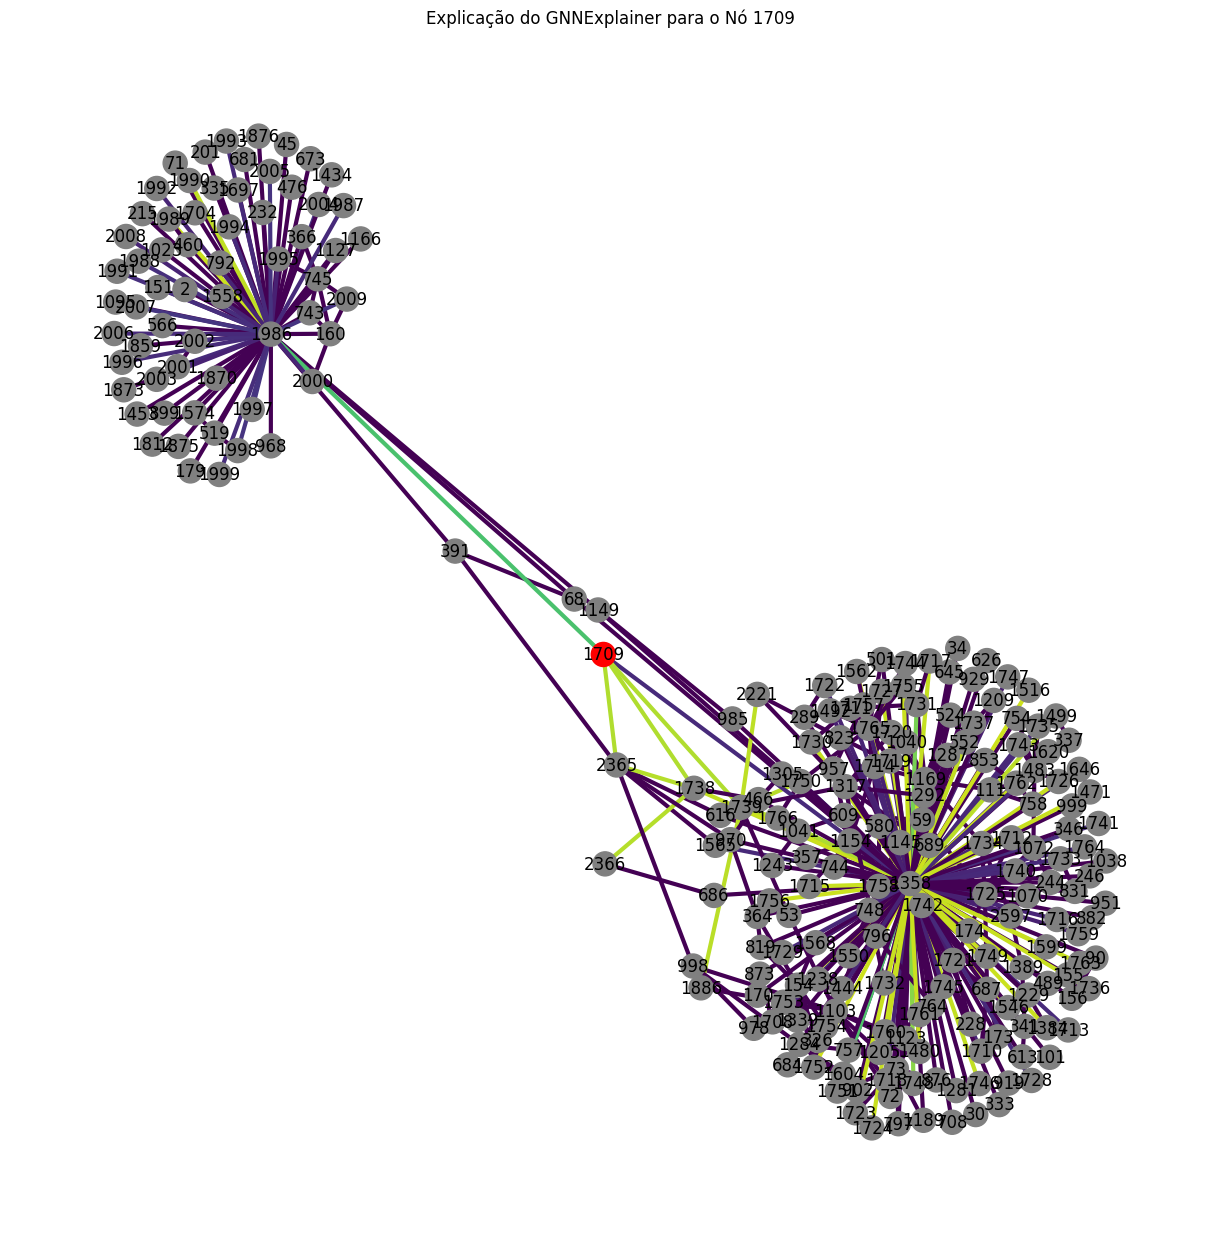

In [4]:
# --- PASSO 3: VISUALIZAR A EXPLICAÇÃO (com a correção) ---

# Converter o grafo do PyG para um formato que o NetworkX entende
G = to_networkx(data, to_undirected=True)
# Extrair o subgrafo da vizinhança
subgraph_nodes = list(nx.ego_graph(G, n=node_idx, radius=2).nodes())
subgraph = G.subgraph(subgraph_nodes)
# Preparar as cores dos nós
node_colors = ['red' if node == node_idx else 'gray' for node in subgraph.nodes()]

# Associar a máscara de arestas às arestas do subgrafo
subgraph_edge_weights = []
for u, v in subgraph.edges():
    # Encontrar a aresta (u,v) ou (v,u) na lista original de arestas
    mask_val_tensor = edge_mask[
        ((data.edge_index[0] == u) & (data.edge_index[1] == v)) |
        ((data.edge_index[0] == v) & (data.edge_index[1] == u))
    ]
    # Pegamos o primeiro item do tensor antes de convertê-lo
    mask_val = mask_val_tensor[0].item()
    subgraph_edge_weights.append(mask_val)

# Desenhar o grafo
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(subgraph, seed=42)
nx.draw(subgraph, pos, with_labels=True, node_color=node_colors,
        width=3,
        edge_color=subgraph_edge_weights,
        edge_cmap=plt.cm.viridis, # Amarelo=importante, Roxo=não importante
        edge_vmin=0, edge_vmax=1)

plt.title(f"Explicação do GNNExplainer para o Nó {node_idx}")
plt.show()

In [5]:
# --- PASSO 4: AVALIAÇÃO (COM MÉTRICAS DO FIDELITY.PY E SPARSITY MANUAL) ---

# Importar as funções de métricas oficiais da biblioteca
# Estas são as funções que existem em fidelity.py
from torch_geometric.explain.metric import (
    fidelity, 
    unfaithfulness
)

print("Calculando métricas oficiais da PyG...")

# --- Métricas Oficiais (de fidelity.py) ---
# A função 'fidelity()' retorna uma tupla: (Fidelity+, Fidelity-)
fid_plus, fid_minus = fidelity(explainer, explanation)

unfaith_val = unfaithfulness(explainer, explanation)

# --- Métrica Manual (Sparsity) ---
# Provamos que esta métrica não é exportada, então calculamos manualmente.
edge_mask = explanation.edge_mask
threshold = edge_mask.mean() # Usamos a média como limiar
num_unimportant_edges = (edge_mask <= threshold).sum().item()
total_edges = edge_mask.numel()
sparsity_val = num_unimportant_edges / total_edges if total_edges > 0 else 0.0

# --- Impressão dos Resultados ---
print("\n--- Métricas de Avaliação da Explicação ---")
print(f"Fidelidade+ (Suficiência / 'faithfulness'): {fid_plus:.4f}")
print(f"  -> (Quanto maior, melhor. Mede a precisão da predição usando *apenas* a explicação)")

print(f"\nFidelidade- (Necessidade / 'necessity'): {fid_minus:.4f}")
print(f"  -> (Quanto maior, melhor. Mede o quanto a predição *cai* ao *remover* a explicação)")

print(f"\nInfidelidade (Unfaithfulness): {unfaith_val:.4f}")
print(f"  -> (Quanto menor, melhor. Mede a diferença entre a predição original e a explicação)")

print(f"\nConcisão (Sparsity): {sparsity_val:.4f}")
print(f"  -> (Quanto maior, melhor. Indica uma explicação mais focada)")

Calculando métricas oficiais da PyG...

--- Métricas de Avaliação da Explicação ---
Fidelidade+ (Suficiência / 'faithfulness'): 1.0000
  -> (Quanto maior, melhor. Mede a precisão da predição usando *apenas* a explicação)

Fidelidade- (Necessidade / 'necessity'): 0.0000
  -> (Quanto maior, melhor. Mede o quanto a predição *cai* ao *remover* a explicação)

Infidelidade (Unfaithfulness): -inf
  -> (Quanto menor, melhor. Mede a diferença entre a predição original e a explicação)

Concisão (Sparsity): 0.9755
  -> (Quanto maior, melhor. Indica uma explicação mais focada)


In [6]:
# --- PASSO 5: VERIFICAR SE A CLASSIFICAÇÃO FOI CORRETA ---

# Obter todas as predições do modelo para o grafo
with torch.no_grad():
    all_predictions_logits = model(data.x, data.edge_index)

# Obter a classe que o modelo previu para o nosso nó específico
predicted_class = all_predictions_logits[node_idx].argmax().item()

# Obter a classe verdadeira do nosso nó (o "gabarito")
true_class = data.y[node_idx].item()

# CORREÇÃO: Definimos a lista de nomes de classes manualmente
class_names = [
    'Theory', 
    'Reinforcement_Learning', 
    'Genetic_Algorithms', 
    'Neural_Networks', 
    'Probabilistic_Methods', 
    'Case_Based', 
    'Rule_Learning'
]

print(f"\n--- Verificação da Classificação para o Nó {node_idx} ---")
print(f"Classe Predita pelo Modelo: {predicted_class} ({class_names[predicted_class]})")
print(f"Classe Verdadeira do Nó:   {true_class} ({class_names[true_class]})")

if predicted_class == true_class:
    print("\nResultado: CLASSIFICAÇÃO CORRETA! ✅")
else:
    print("\nResultado: CLASSIFICAÇÃO INCORRETA! ❌")


--- Verificação da Classificação para o Nó 1709 ---
Classe Predita pelo Modelo: 2 (Genetic_Algorithms)
Classe Verdadeira do Nó:   2 (Genetic_Algorithms)

Resultado: CLASSIFICAÇÃO CORRETA! ✅


--- Iniciando Avaliação em Lote (50 nós) no dataset Cora ---


Explicando nós: 100%|██████████| 50/50 [07:59<00:00,  9.60s/it]



--- Resultados da Avaliação em Lote ---
Dataset: Cora
Nós avaliados: 50
Fidelidade+ (Suficiência): 0.5400 ± 0.4984
Fidelidade- (Necessidade): 0.0000 ± 0.0000
Concisão (Sparsity)      : 0.9953


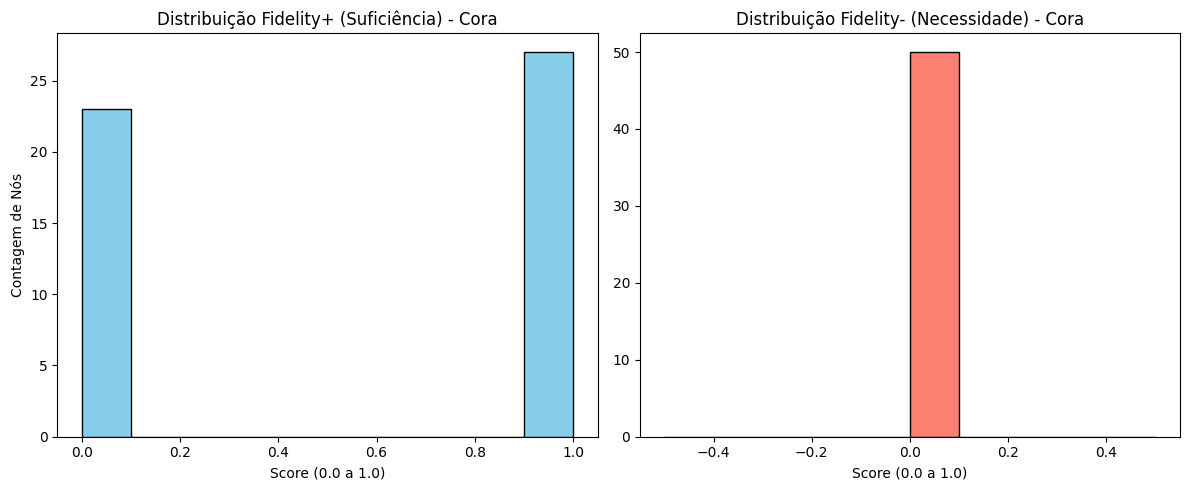

In [7]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm  # Barra de progresso
from torch_geometric.explain.metric import fidelity

def avaliar_em_lote(dataset, data, model, explainer, num_nodes=50):
    """
    Executa o explainer em um lote de nós de teste e retorna estatísticas.
    """
    print(f"--- Iniciando Avaliação em Lote ({num_nodes} nós) no dataset {dataset.name} ---")
    
    # 1. Selecionar nós aleatórios do conjunto de teste (test_mask)
    # Convertemos a máscara booleana em índices
    test_indices = data.test_mask.nonzero(as_tuple=False).view(-1).tolist()
    
    # Se pedirmos mais nós do que existem, usamos todos
    if num_nodes > len(test_indices):
        num_nodes = len(test_indices)
    
    selected_nodes = random.sample(test_indices, num_nodes)
    
    # Listas para guardar os resultados
    fids_plus = []
    fids_minus = []
    sparsities = []
    
    # 2. Loop principal (com barra de progresso)
    model.eval()
    for node_idx in tqdm(selected_nodes, desc="Explicando nós"):
        # Gerar explicação
        explanation = explainer(data.x, data.edge_index, index=node_idx)
        
        # Calcular Fidelity (Oficial)
        # Retorna tupla (Fidelity+, Fidelity-)
        fid_p, fid_m = fidelity(explainer, explanation)
        
        # Calcular Sparsity (Manual)
        edge_mask = explanation.edge_mask
        if edge_mask is not None and edge_mask.numel() > 0:
            threshold = edge_mask.mean()
            num_unimportant = (edge_mask <= threshold).sum().item()
            sparsity_val = num_unimportant / edge_mask.numel()
        else:
            sparsity_val = 0.0
            
        # Guardar métricas
        fids_plus.append(fid_p)
        fids_minus.append(fid_m)
        sparsities.append(sparsity_val)

    # 3. Calcular Estatísticas
    results = {
        "fid_plus_mean": np.mean(fids_plus),
        "fid_plus_std": np.std(fids_plus),
        "fid_minus_mean": np.mean(fids_minus),
        "fid_minus_std": np.std(fids_minus),
        "sparsity_mean": np.mean(sparsities),
        "data_raw": (fids_plus, fids_minus, sparsities) # Guardamos os dados brutos para plotar
    }
    
    print("\n--- Resultados da Avaliação em Lote ---")
    print(f"Dataset: {dataset.name}")
    print(f"Nós avaliados: {num_nodes}")
    print(f"Fidelidade+ (Suficiência): {results['fid_plus_mean']:.4f} ± {results['fid_plus_std']:.4f}")
    print(f"Fidelidade- (Necessidade): {results['fid_minus_mean']:.4f} ± {results['fid_minus_std']:.4f}")
    print(f"Concisão (Sparsity)      : {results['sparsity_mean']:.4f}")
    
    return results

def plotar_distribuicao(results, dataset_name):
    """Plota histogramas das métricas para visualizarmos o comportamento."""
    fid_p, fid_m, _ = results['data_raw']
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histograma Fidelity+
    ax[0].hist(fid_p, bins=10, color='skyblue', edgecolor='black')
    ax[0].set_title(f"Distribuição Fidelity+ (Suficiência) - {dataset_name}")
    ax[0].set_xlabel("Score (0.0 a 1.0)")
    ax[0].set_ylabel("Contagem de Nós")
    
    # Histograma Fidelity-
    ax[1].hist(fid_m, bins=10, color='salmon', edgecolor='black')
    ax[1].set_title(f"Distribuição Fidelity- (Necessidade) - {dataset_name}")
    ax[1].set_xlabel("Score (0.0 a 1.0)")
    
    plt.tight_layout()
    plt.show()

# --- EXECUÇÃO PARA O CORA ---
# Usamos as variáveis 'dataset', 'data', 'model' e 'explainer' que você já tem carregadas
resultados_cora = avaliar_em_lote(dataset, data, model, explainer, num_nodes=50)
plotar_distribuicao(resultados_cora, "Cora")

--- Iniciando Experimento no Dataset CiteSeer ---
Dataset carregado: CiteSeer
Nós: 3327, Arestas: 9104, Classes: 6
Treinando modelo GCN no CiteSeer...
Treinamento concluído.
--- Iniciando Avaliação em Lote (50 nós) no dataset CiteSeer ---


Explicando nós: 100%|██████████| 50/50 [28:41<00:00, 34.44s/it]



--- Resultados da Avaliação em Lote ---
Dataset: CiteSeer
Nós avaliados: 50
Fidelidade+ (Suficiência): 0.9000 ± 0.3000
Fidelidade- (Necessidade): 0.1200 ± 0.3250
Concisão (Sparsity)      : 0.9978


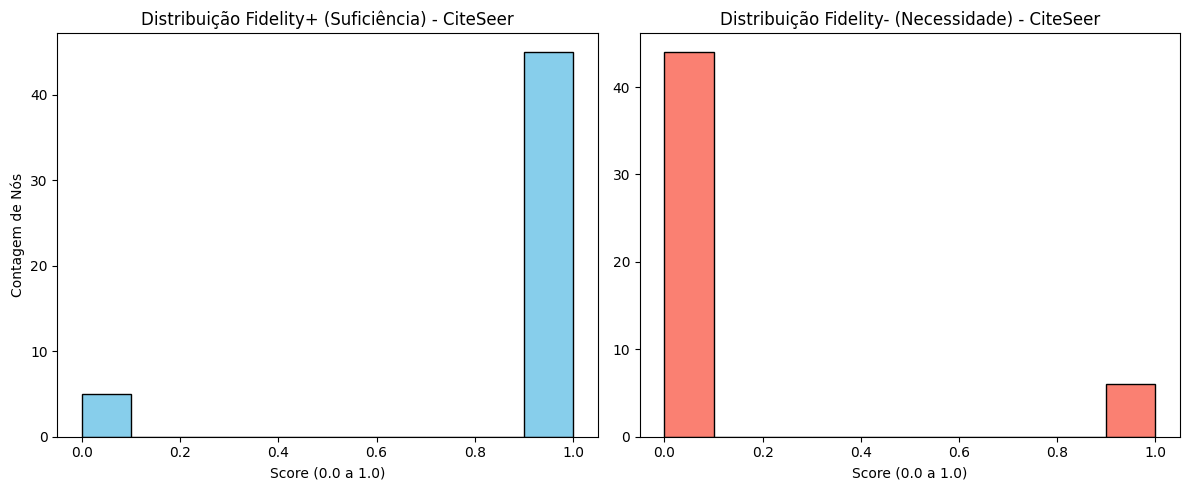

In [9]:
# --- PASSO 8: VALIDAÇÃO CRUZADA NO DATASET CITESEER ---
from torch_geometric.datasets import Planetoid
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

print("--- Iniciando Experimento no Dataset CiteSeer ---")

# 1. Carregar o Dataset CiteSeer
# Usamos NormalizeFeatures para ajudar o modelo a convergir mais rápido
dataset_cs = Planetoid(root='data/CiteSeer', name='CiteSeer', transform=T.NormalizeFeatures())
data_cs = dataset_cs[0]

print(f"Dataset carregado: {dataset_cs.name}")
print(f"Nós: {data_cs.num_nodes}, Arestas: {data_cs.num_edges}, Classes: {dataset_cs.num_classes}")

# 2. Definir e Treinar um NOVO Modelo GCN para o CiteSeer
# (Não podemos usar o modelo do Cora, pois o número de features e classes é diferente)
class GCN_CiteSeer(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset_cs.num_features, 16)
        self.conv2 = GCNConv(16, dataset_cs.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_cs = GCN_CiteSeer().to(device)
data_cs = data_cs.to(device)
optimizer_cs = torch.optim.Adam(model_cs.parameters(), lr=0.01, weight_decay=5e-4)

print("Treinando modelo GCN no CiteSeer...")
model_cs.train()
for epoch in range(200):
    optimizer_cs.zero_grad()
    out = model_cs(data_cs.x, data_cs.edge_index)
    loss = F.cross_entropy(out[data_cs.train_mask], data_cs.y[data_cs.train_mask])
    loss.backward()
    optimizer_cs.step()
print("Treinamento concluído.")

# 3. Configurar o GNNExplainer para este novo modelo
from torch_geometric.explain import Explainer, GNNExplainer

explainer_cs = Explainer(
    model=model_cs,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='object',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

# 4. Rodar a Avaliação em Lote (Reusando a função que criamos antes)
# Vamos avaliar 50 nós também para ser comparável
resultados_cs = avaliar_em_lote(dataset_cs, data_cs, model_cs, explainer_cs, num_nodes=50)

# 5. Plotar os Histogramas Comparativos
plotar_distribuicao(resultados_cs, "CiteSeer")